# IT APPLIES ON NOMINAL DATA

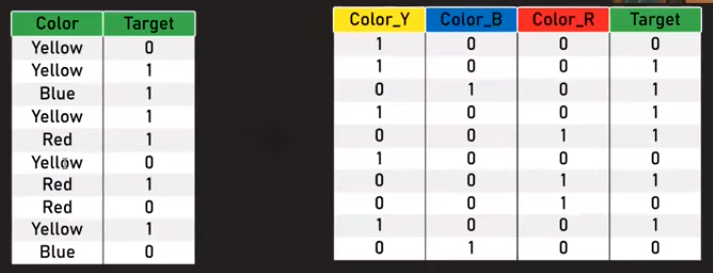

# DUMY VARIABLE TRAP

- THE COLUMNS FORMED ARE DUMY VARIABLES BUT THEY ARE RELATED TO EACH OTHER (i.e THEIR SUM IS ALWAYS EQUAL TO 1 ) THIS IS CALED **MULTICOLLINEARITY** WHICH IS REALLY BAD ESPECIALLY FOR LINEAR MODELS.

- IN ORDER TO OVERCOME THIS PROBLEM WE ALWAYS USED **N-1 COLUMNS**.MEANS WE WILL SIMPLY REMOVE THE 1ST COLUMN.



# OHE USING MOST FREQUENT VARIABLE

WE SIMPLY SEPARATE THE MOST FREQUENT CATEGORIES AS INDIVIDUAL COLUMNS AND COMBINE ALL OTHER LESS VALUES CONTAINING CATEGORIES INTO **"OTHERS"** COLUMN



---



---



In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv('cars.csv')
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [ ]:
df.shape

(8128, 5)

In [ ]:
df['brand'].nunique()

32

In [ ]:
df['brand'].value_counts()

Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Force               6
Land                6
Isuzu               5
Kia                 4
Ambassador          4
Daewoo              3
MG                  3
Ashok               1
Opel                1
Peugeot             1
Name: brand, dtype: int64

In [ ]:
df['fuel'].value_counts()

Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: fuel, dtype: int64

In [ ]:
df['owner'].value_counts()

First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: owner, dtype: int64

#1. OneHotEncoding using Pandas

In [ ]:
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


#2. K-1 OneHotEncoding

In [ ]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


#3. OneHotEncoding using Sklearn

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


- IF WE DONT USE SPARSE THEN WE HAVE TO USE **toarray()** IN ORDER TO SEE THE NUMPY ARRAY BUT IF WE PROVIDE THE FALSE VALUE OF SPARSE THEN WE DONT NEED IT
- **DTYPE** PARAMETER IS USED TO CONVERT THE FLOAT VALUES INTO INTEGERS.
- **DROP FIRST** IS USED FOR MULTICOLLINEARITY ISSUE

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first',sparse=False,dtype=np.int32)
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])
X_test_new = ohe.transform(X_test[['fuel','owner']])
X_train_new.shape

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(6502, 7)

In [ ]:
# NORMALLY WE USED TRANSFORMERS BUT HERE WE ADD THE TWO DATASETS SEPARATELY
np.hstack((X_train[['brand','km_driven']].values,X_train_new))

array([['Hyundai', 35000, 1, ..., 0, 0, 0],
       ['Jeep', 60000, 1, ..., 0, 0, 0],
       ['Hyundai', 25000, 0, ..., 0, 0, 0],
       ...,
       ['Tata', 15000, 0, ..., 0, 0, 0],
       ['Maruti', 32500, 1, ..., 1, 0, 0],
       ['Isuzu', 121000, 1, ..., 0, 0, 0]], dtype=object)

# 4. OneHotEncoding with Top Categories (BY PANDAS)

In [ ]:
counts = df['brand'].value_counts()
df['brand'].nunique()
threshold = 100
repl = counts[counts <= threshold].index
pd.get_dummies(df['brand'].replace(repl, 'uncommon')).sample(5)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
6361,0,0,0,0,0,1,0,0,0,0,0,0,0
7892,0,0,0,0,0,0,0,0,0,0,1,0,0
2477,0,0,0,0,0,0,1,0,0,0,0,0,0
5005,0,0,0,0,0,0,0,0,0,0,0,0,1
6698,0,0,0,0,0,0,0,0,0,0,1,0,0
